In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df=pd.read_csv('emi_cleaned.csv')

In [3]:
df.shape

(392904, 27)

In [4]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,F,Married,Professional,82600,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38,F,Married,Graduate,21500,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38,M,Married,Professional,86100,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58,F,Married,High School,66800,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48,F,Married,Professional,57300,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [5]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='str')

label encoding for features

In [6]:
df['gender'].value_counts()

gender
M    235821
F    157083
Name: count, dtype: int64

In [7]:
gender_map={
    'M':'0',
    'F':'1',
}
df['gender']=df['gender'].replace(gender_map)
df['gender']=df['gender'].astype(int)

In [8]:
marital_status_map={
    'Single':'0',
    'Married':'1'
}
df['marital_status']=df['marital_status'].replace(marital_status_map)
df['marital_status']=df['marital_status'].astype(int)

In [9]:
df['education'].value_counts()

education
Graduate         175719
Post Graduate     97348
High School       58917
Professional      58588
Unknown            2332
Name: count, dtype: int64

In [10]:
education_map={
    'Unknown':'0',
    'High School':'1',
    'Post Graduate':'3',
    'Professional':'4',
    'Graduate':'2',
}
df['education']=df['education'].replace(education_map)
df['education']=df['education'].astype(int)

In [11]:
df['employment_type'].value_counts()

employment_type
Private          274747
Government        78773
Self-employed     39384
Name: count, dtype: int64

In [12]:
df['company_type'].value_counts()

company_type
Large Indian    117486
MNC              98436
Mid-size         98347
Startup          58994
Small            19641
Name: count, dtype: int64

In [13]:
company_map={
    'Small':'0',
    'Startup':'1',
    'Mid-size':'2',
    'Large Indian':'3',
    'MNC':'4'
}
df['company_type']=df['company_type'].replace(company_map)
df['company_type']=df['company_type'].astype(int)

In [14]:
df['existing_loans'].value_counts()

existing_loans
No     236133
Yes    156771
Name: count, dtype: int64

In [15]:
existing_loan_map={
    'No':'0',
    'Yes':'1'
}
df['existing_loans']=df['existing_loans'].replace(existing_loan_map)
df['existing_loans']=df['existing_loans'].astype(int)

In [16]:
df.to_csv('lr.csv',index=False)

### ONe hot encoding 

In [ ]:
cols_to_encode=['house_type','employment_type','emi_scenario']
df=pd.get_dummies(df,columns=cols_to_encode,prefix=cols_to_encode,dtype=int)

In [18]:
df.head()

,age,gender,marital_status,education,monthly_salary,years_of_employment,company_type,monthly_rent,family_size,dependents,...,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,house_type_Family,house_type_Own,house_type_Rented,employment_type_Government,employment_type_Private,employment_type_Self-employed
0,38,1,1,4,82600,0.9,2,20000.0,3,2,...,850000.0,15,Not_Eligible,500.0,0,0,1,0,1,0
1,38,1,1,2,21500,7.0,4,0.0,2,1,...,128000.0,19,Not_Eligible,700.0,1,0,0,0,1,0
2,38,0,1,4,86100,5.8,1,0.0,4,3,...,306000.0,16,Eligible,27775.0,0,1,0,0,1,0
3,58,1,1,1,66800,2.2,2,0.0,5,4,...,304000.0,83,Eligible,16170.0,0,1,0,0,1,0
4,48,1,1,4,57300,3.4,2,0.0,4,3,...,252000.0,7,Not_Eligible,500.0,1,0,0,0,1,0


In [19]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 392904 entries, 0 to 392903
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   age                            392904 non-null  int64  
 1   gender                         392904 non-null  int64  
 2   marital_status                 392904 non-null  int64  
 3   education                      392904 non-null  int64  
 4   monthly_salary                 392904 non-null  int64  
 5   years_of_employment            392904 non-null  float64
 6   company_type                   392904 non-null  int64  
 7   monthly_rent                   392904 non-null  float64
 8   family_size                    392904 non-null  int64  
 9   dependents                     392904 non-null  int64  
 10  school_fees                    392904 non-null  float64
 11  college_fees                   392904 non-null  float64
 12  travel_expenses                392904 non

In [20]:
df.corr(numeric_only=True)

,age,gender,marital_status,education,monthly_salary,years_of_employment,company_type,monthly_rent,family_size,dependents,...,emergency_fund,requested_amount,requested_tenure,max_monthly_emi,house_type_Family,house_type_Own,house_type_Rented,employment_type_Government,employment_type_Private,employment_type_Self-employed
age,1.000000,0.000367,0.353013,-0.000151,-0.000581,0.479555,0.001440,-0.000044,0.209210,0.209210,...,-0.002194,0.001426,0.000088,-0.000474,0.000045,0.000671,-0.000694,0.001528,-0.001465,0.000199
gender,0.000367,1.000000,0.000063,-0.002122,-0.001655,-0.000775,-0.003004,-0.003301,-0.001260,-0.001260,...,-0.004019,0.001350,0.001418,-0.001854,0.002289,-0.000411,-0.001621,-0.001213,0.000285,0.001181
marital_status,0.353013,0.000063,1.000000,-0.002454,-0.001287,0.168278,0.000829,-0.001792,0.593699,0.593699,...,-0.002999,0.000342,-0.001265,-0.054943,0.003136,0.000198,-0.002963,0.001341,-0.000824,-0.000529
education,-0.000151,-0.002122,-0.002454,1.000000,0.255029,-0.000615,-0.001616,0.127221,0.000536,0.000536,...,0.234987,-0.000637,-0.003377,0.228147,-0.000374,0.000353,-0.000013,0.001660,-0.001376,-0.000111
monthly_salary,-0.000581,-0.001655,-0.001287,0.255029,1.000000,-0.000219,-0.001572,0.207341,-0.000583,-0.000583,...,0.384584,-0.001997,0.000097,0.379301,-0.000509,0.003015,-0.002490,-0.001218,0.001218,-0.000236
years_of_employment,0.479555,-0.000775,0.168278,-0.000615,-0.000219,1.000000,0.000605,0.000446,0.101668,0.101668,...,-0.001157,0.001385,-0.000706,0.028795,0.001143,-0.001973,0.000914,-0.000625,-0.000170,0.001094
company_type,0.001440,-0.003004,0.000829,-0.001616,-0.001572,0.000605,1.000000,-0.002735,-0.000300,-0.000300,...,-0.001541,0.001114,0.002907,0.000350,-0.000531,0.001322,-0.000820,-0.000504,0.000969,-0.000808
monthly_rent,-0.000044,-0.003301,-0.001792,0.127221,0.207341,0.000446,-0.002735,1.000000,-0.001981,-0.001981,...,0.188792,-0.000974,0.000511,-0.169456,-0.368740,-0.471193,0.785043,-0.000300,0.001217,-0.001460
family_size,0.209210,-0.001260,0.593699,0.000536,-0.000583,0.101668,-0.000300,-0.001981,1.000000,1.000000,...,-0.002533,0.000604,-0.002343,-0.061947,0.002741,0.000489,-0.002897,0.003047,-0.003593,0.001423
dependents,0.209210,-0.001260,0.593699,0.000536,-0.000583,0.101668,-0.000300,-0.001981,1.000000,1.000000,...,-0.002533,0.000604,-0.002343,-0.061947,0.002741,0.000489,-0.002897,0.003047,-0.003593,0.001423


In [21]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'years_of_employment', 'company_type', 'monthly_rent', 'family_size',
       'dependents', 'school_fees', 'college_fees', 'travel_expenses',
       'groceries_utilities', 'other_monthly_expenses', 'existing_loans',
       'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund',
       'emi_scenario', 'requested_amount', 'requested_tenure',
       'emi_eligibility', 'max_monthly_emi', 'house_type_Family',
       'house_type_Own', 'house_type_Rented', 'employment_type_Government',
       'employment_type_Private', 'employment_type_Self-employed'],
      dtype='str')

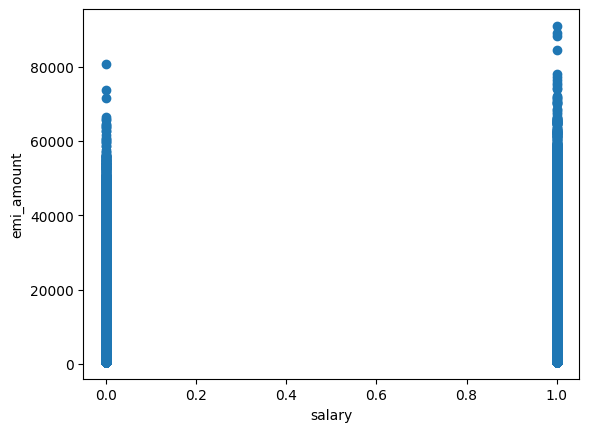

In [22]:
plt.scatter(df['marital_status'],df['max_monthly_emi'])
plt.xlabel('salary')
plt.ylabel('emi_amount')
plt.show()

<Axes: xlabel='emi_eligibility', ylabel='monthly_salary'>

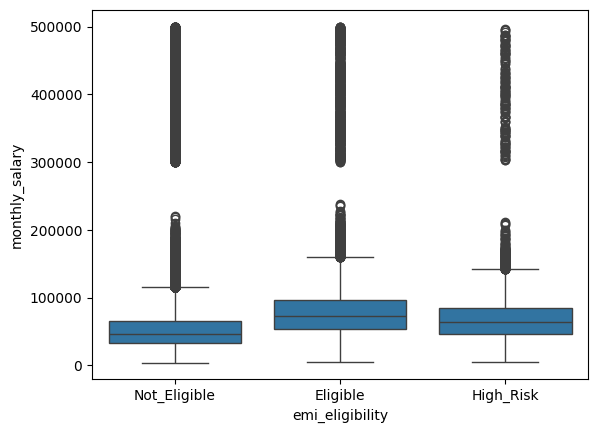

In [23]:
sns.boxplot(x='emi_eligibility',y='monthly_salary',data=df)

<Axes: xlabel='credit_score', ylabel='monthly_salary'>

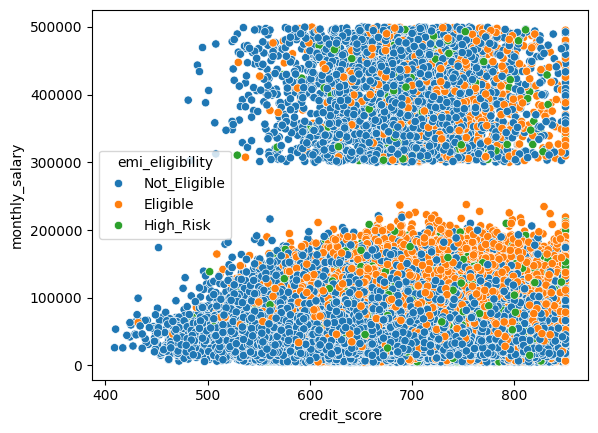

In [24]:
sns.scatterplot(data=df,x='credit_score',y='monthly_salary',hue='emi_eligibility')

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

SyntaxError: trailing comma not allowed without surrounding parentheses (3516406830.py, line 3)

In [ ]:
target_map={
    'Not_Eligible':'0',
    'High_Risk':'1',
    'Eligible':'2'
}
df['emi_eligibility']=df['emi_eligibility'].replace(target_map)
df['emi_eligibility']=df['emi_eligibility'].astype(int)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392904 entries, 0 to 392903
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   age                            392904 non-null  int64  
 1   gender                         392904 non-null  int64  
 2   marital_status                 392904 non-null  int64  
 3   education                      392904 non-null  int64  
 4   monthly_salary                 392904 non-null  int64  
 5   years_of_employment            392904 non-null  float64
 6   company_type                   392904 non-null  int64  
 7   monthly_rent                   392904 non-null  float64
 8   family_size                    392904 non-null  int64  
 9   dependents                     392904 non-null  int64  
 10  school_fees                    392904 non-null  float64
 11  college_fees                   392904 non-null  float64
 12  travel_expenses                392904 non

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'years_of_employment', 'company_type', 'monthly_rent', 'family_size',
       'dependents', 'school_fees', 'college_fees', 'travel_expenses',
       'groceries_utilities', 'other_monthly_expenses', 'existing_loans',
       'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund',
       'emi_scenario', 'requested_amount', 'requested_tenure',
       'emi_eligibility', 'max_monthly_emi', 'house_type_Family',
       'house_type_Own', 'house_type_Rented', 'employment_type_Government',
       'employment_type_Private', 'employment_type_Self-employed'],
      dtype='str')

In [ ]:
X= df.drop(columns=['max_monthly_emi','gender','requested_tenure','emi_scenario'])
y=df['max_monthly_emi']

In [ ]:
correlations = df.corr()['max_monthly_emi'].sort_values(ascending=False)
correlations

ValueError: could not convert string to float: 'Personal Loan EMI'

In [ ]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 392904 entries, 0 to 392903
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   age                            392904 non-null  int64  
 1   marital_status                 392904 non-null  int64  
 2   education                      392904 non-null  int64  
 3   monthly_salary                 392904 non-null  int64  
 4   years_of_employment            392904 non-null  float64
 5   company_type                   392904 non-null  int64  
 6   monthly_rent                   392904 non-null  float64
 7   family_size                    392904 non-null  int64  
 8   dependents                     392904 non-null  int64  
 9   school_fees                    392904 non-null  float64
 10  college_fees                   392904 non-null  float64
 11  travel_expenses                392904 non-null  float64
 12  groceries_utilities            392904 non

In [ ]:
# from sklearn.preprocessing import PolynomialFeatures

# poly = PolynomialFeatures(degree=2, include_bias=False)
# X_poly = poly.fit_transform(X)

In [ ]:
st = StandardScaler()
X_scaled=st.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor()
rf_regressor.fit(X_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
preds=rf_regressor.predict(X_test)

In [ ]:
mean_squared_error(y_test, preds)

1999329.8409400263

In [ ]:
rmse=np.sqrt(np.mean((y_test-preds)**2))
rmse

np.float64(1413.9766055136931)

In [ ]:
r2_score(y_test, preds)

0.9665030686272081

In [ ]:
lr_emi_predict= LinearRegression()
lr_emi_predict.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
lr_emi_predict.coef_

array([   13.76294303,     3.56783465,   320.21470994,   800.26173771,
         130.14856665,     3.8999343 , -1868.8565747 ,   -24.44519444,
         -24.44519444, -1328.15364269, -1601.91081472,   925.36495421,
        1975.66091014,    62.76574641,  -398.2248456 , -2351.2979644 ,
         851.7011752 ,  1671.70315987,    21.35994095,   574.8555462 ,
        1852.62613836,   197.90380483,   208.99319688,  -378.5391032 ,
         143.61626815,   -43.58467355,  -124.90891583])

In [ ]:
preds=lr_emi_predict.predict(X_test)

In [ ]:
mean_squared_error(y_test, preds)

14671808.375620028

In [ ]:
rmse=np.sqrt(np.mean((y_test-preds)**2))
rmse

np.float64(3830.3796646833885)

In [ ]:
r2_score(y_test, preds)

0.7541873540776907

In [ ]:
lasso_emi= Lasso(alpha=1)
lasso_emi.fit(X_train,y_train)
lasso_emi.coef_

array([ 1.33635325e+01,  1.19165058e+00,  3.19497033e+02,  7.99662084e+02,
        1.29486968e+02,  2.90607543e+00, -1.86688835e+03, -4.66010531e+01,
       -3.19251282e-11, -1.32712013e+03, -1.60091855e+03,  9.24832690e+02,
        1.97521753e+03,  6.22493975e+01, -3.98832992e+02, -2.34927353e+03,
        8.51548911e+02,  1.67158831e+03,  2.08346772e+01,  5.73902205e+02,
        1.85277716e+03,  7.91572889e+00,  0.00000000e+00, -5.93740915e+02,
        1.80844387e+02, -0.00000000e+00, -9.55244225e+01])

In [ ]:
preds=lasso_emi.predict(X_test)
print(mean_squared_error(y_test, preds))
print(r2_score(y_test, preds))

14671711.258231211
0.754188981190157
